# Marketing Campaign Performance Modeling  
*Modeling conversions using ad spend, targeting, creative quality, and interaction terms.*

## 1. Business Question

Marketing teams invest across multiple channels, audiences, and creatives.  
I want to understand:

**Which campaign variables drive conversions, and how do they interact?**

Key objectives:
- Identify the strongest predictors of conversions.
- Examine **interaction effects** (e.g., Spend × Audience Size).
- Provide actionable recommendations for budget allocation.

In [2]:
!pip install seaborn

In [3]:
import seaborn as sns

In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

## 2. Dataset Overview

I simulate a campaign-level dataset with the following features:

- `ad_spend` — daily budget for the campaign (in €)
- `audience_size` — size of the target audience
- `creative_quality` — subjective 1–5 score of the creative
- `landing_page_quality` — 1–5 score for landing page UX
- `seasonality_factor` — numeric season index (e.g. 0.8 = off-season, 1.2 = peak)
- `conversions` — number of conversions generated by the campaign

The relationships are designed so that:

- Higher spend, better creatives, better landing pages, larger audiences, and peak seasons → more conversions.
- **Interaction effects** exist, e.g.:
  - Good creatives scale better with higher spend.
  - Large audiences perform better with higher budgets.

In [5]:
n = 1000  # number of campaigns

# Base features
ad_spend = np.random.uniform(500, 5000, size=n)  # euros
audience_size = np.random.uniform(20_000, 500_000, size=n)  # people
creative_quality = np.random.uniform(1, 5, size=n)  # 1-5
landing_page_quality = np.random.uniform(1, 5, size=n)  # 1-5

# Seasonality: low, mid, peak mapped to numeric factors
season_choices = np.random.choice(["low", "mid", "peak"], size=n, p=[0.3, 0.4, 0.3])
season_factor_map = {"low": 0.8, "mid": 1.0, "peak": 1.2}
seasonality_factor = np.array([season_factor_map[s] for s in season_choices])

# Rescale some features for nicer coefficients
spend_k = ad_spend / 1000        # thousands of €
aud_100k = audience_size / 100_000  # in units of 100k

# True underlying relationship (this is the "data generating process")
noise = np.random.normal(0, 10, size=n)

conversions = (
    20
    + 8 * spend_k
    + 15 * aud_100k
    + 4 * creative_quality
    + 3 * landing_page_quality
    + 10 * seasonality_factor
    + 5 * spend_k * creative_quality              # interaction: spend × creative
    + 8 * creative_quality * seasonality_factor   # interaction: creative × season
    + noise
)

# Ensure conversions are non-negative and round to integers
conversions = np.clip(conversions, a_min=0, a_max=None)
conversions = np.round(conversions).astype(int)

# Build DataFrame
df = pd.DataFrame({
    "ad_spend": ad_spend,
    "audience_size": audience_size,
    "creative_quality": creative_quality,
    "landing_page_quality": landing_page_quality,
    "seasonality_factor": seasonality_factor,
    "season_label": season_choices,
    "conversions": conversions,
})

df.head()

,ad_spend,audience_size,creative_quality,landing_page_quality,seasonality_factor,season_label,conversions
0,2185.430535,108863.805843,2.046823,3.690812,1.0,mid,116
1,4778.214379,280112.454742,1.987915,4.186726,1.2,peak,175
2,3793.972738,439014.001221,4.625018,2.001872,1.2,peak,281
3,3193.963179,371467.945477,1.998185,3.499496,0.8,low,182
4,1202.083882,407149.350973,2.087799,3.286984,0.8,low,148


### 2.1 Preview of the Data

Let's quickly inspect the dataset to get a sense of the feature ranges and target distribution.

,count,mean,std,min,25%,50%,75%,max
ad_spend,1000.0,2706.154490,1314.618129,520.844104,1561.879704,2735.633194,3849.438146,4998.729530
audience_size,1000.0,263368.306486,140251.148834,21544.766530,135715.650156,268992.275085,385023.227527,499718.588370
creative_quality,1000.0,3.009623,1.162697,1.000047,2.045404,3.002456,4.036414,4.991283
landing_page_quality,1000.0,2.961500,1.145957,1.002614,1.967603,2.937117,3.950163,4.998231
seasonality_factor,1000.0,0.996000,0.153126,0.800000,0.800000,1.000000,1.200000,1.200000
conversions,1000.0,176.333000,50.066723,67.000000,141.000000,172.000000,209.250000,320.000000


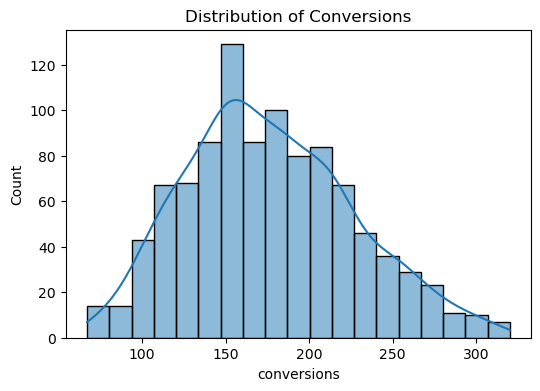

In [6]:
display(df.describe().T)

plt.figure(figsize=(6, 4))
sns.histplot(df["conversions"], kde=True)
plt.title("Distribution of Conversions")
plt.show()

## 3. Feature Engineering

The base features already carry useful information, but in marketing we often care about **how variables work together**, for example:

- Does a good creative amplify the effect of ad spend?
- Are large audiences more responsive when spend is high?
- Do great creatives perform especially well in peak season?

To capture these effects, I create **interaction terms**.

### 3.1 Creating Interaction Terms

I add the following interactions:

- `spend_x_creative` = ad_spend × creative_quality  
- `spend_x_audience` = ad_spend × audience_size  
- `creative_x_season` = creative_quality × seasonality_factor  

These reflect realistic marketing hypotheses:

- Good creatives scale better with more budget.
- Higher budgets are more effective on larger audiences.
- Creative quality matters more in peak seasons.

In [7]:
df["spend_x_creative"] = df["ad_spend"] * df["creative_quality"]
df["spend_x_audience"] = df["ad_spend"] * df["audience_size"]
df["creative_x_season"] = df["creative_quality"] * df["seasonality_factor"]

df[[
    "ad_spend",
    "creative_quality",
    "seasonality_factor",
    "spend_x_creative",
    "spend_x_audience",
    "creative_x_season"
]].head()

,ad_spend,creative_quality,seasonality_factor,spend_x_creative,spend_x_audience,creative_x_season
0,2185.430535,2.046823,1.0,4473.188904,2.379143e+08,2.046823
1,4778.214379,1.987915,1.2,9498.684975,1.338437e+09,2.385498
2,3793.972738,4.625018,1.2,17547.193427,1.665607e+09,5.550022
3,3193.963179,1.998185,0.8,6382.128674,1.186455e+09,1.598548
4,1202.083882,2.087799,0.8,2509.709412,4.894277e+08,1.670239


## 4. Modeling Approach

I use a **Linear Regression** model to predict `conversions` based on:

- Base features:
  - `ad_spend`
  - `audience_size`
  - `creative_quality`
  - `landing_page_quality`
  - `seasonality_factor`

- Interaction features:
  - `spend_x_creative`
  - `spend_x_audience`
  - `creative_x_season`

I split the data into **train/test** sets and evaluate performance using:

- **R²** (explained variance)
- **MAE** (mean absolute error)

The goal is not just predictive power, but also **interpretable coefficients** to support marketing decisions.

In [8]:
feature_cols = [
    "ad_spend",
    "audience_size",
    "creative_quality",
    "landing_page_quality",
    "seasonality_factor",
    "spend_x_creative",
    "spend_x_audience",
    "creative_x_season",
]

X = df[feature_cols].values
y = df["conversions"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred = linreg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, r2

(8.068218751447649, 0.9543310864592551)

## 5. Model Results & Interpretation

First, I inspect the overall performance:

- **R²**: how much variance in conversions the model explains.
- **MAE**: average absolute error between predicted and actual conversions.

Then I look at the coefficients to understand:

- Which features have the largest positive/negative impact?
- Whether interaction terms matter in addition to base features.

In [9]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": linreg.coef_,
})

coef_df.sort_values(by="coefficient", ascending=False)

,feature,coefficient
7,creative_x_season,9.773713e+00
3,landing_page_quality,2.659452e+00
2,creative_quality,2.071840e+00
4,seasonality_factor,1.846854e+00
0,ad_spend,8.830902e-03
5,spend_x_creative,4.961505e-03
1,audience_size,1.575950e-04
6,spend_x_audience,-2.290903e-09


### 5.1 Quick Visual Checks

I also create a few simple plots to see how predictions compare to actuals, and how conversions vary with key features.

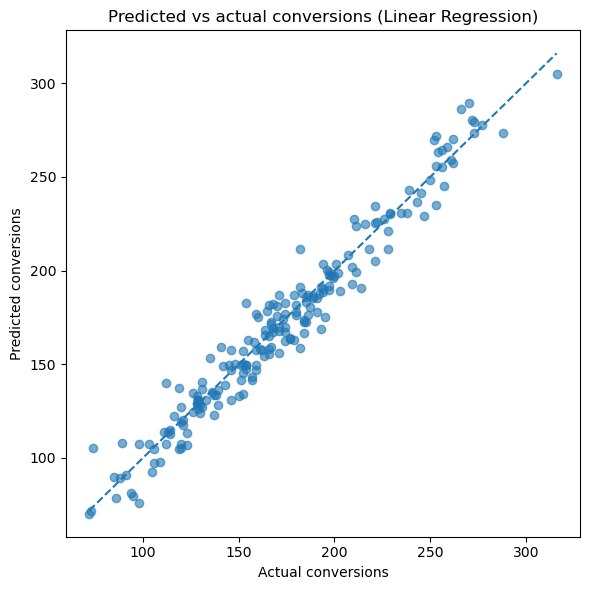

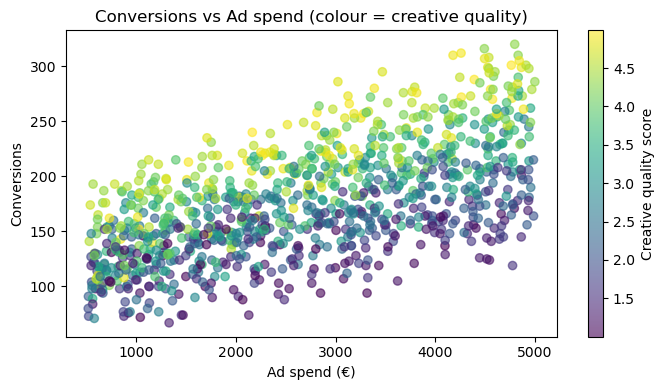

In [10]:
# Predictions vs actual conversions (Linear Regression)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual conversions")
plt.ylabel("Predicted conversions")
plt.title("Predicted vs actual conversions (Linear Regression)")
plt.tight_layout()
plt.show()

# Example: conversions vs ad_spend, coloured by creative quality
plt.figure(figsize=(7, 4))
sc = plt.scatter(
    df["ad_spend"],
    df["conversions"],
    c=df["creative_quality"],
    alpha=0.6
)
plt.xlabel("Ad spend (€)")
plt.ylabel("Conversions")
plt.title("Conversions vs Ad spend (colour = creative quality)")
cbar = plt.colorbar(sc)
cbar.set_label("Creative quality score")
plt.tight_layout()
plt.show()

### 5. Feature Engineering: Interaction Terms

Marketing channels often influence each other.  
For example:

- **Spend × Audience Size** → Big audiences respond differently at higher spend levels  
- **Spend × Email CTR** → Performance changes depending on engagement quality  
- **Audience Size × Email CTR** → Large audiences with high CTR perform exceptionally well  

Here we create interaction terms to capture these *nonlinear combined effects*.

In [13]:
df.columns.tolist()

['ad_spend',
 'audience_size',
 'creative_quality',
 'landing_page_quality',
 'seasonality_factor',
 'season_label',
 'conversions',
 'spend_x_creative',
 'spend_x_audience',
 'creative_x_season']

In [15]:
# Create interaction features using correct column names
df["spend_x_audience"] = df["ad_spend"] * df["audience_size"]
df["spend_x_creative"]  = df["ad_spend"] * df["creative_quality"]
df["creative_x_season"] = df["creative_quality"] * df["seasonality_factor"]

df.head()

,ad_spend,audience_size,creative_quality,landing_page_quality,seasonality_factor,season_label,conversions,spend_x_creative,spend_x_audience,creative_x_season
0,2185.430535,108863.805843,2.046823,3.690812,1.0,mid,116,4473.188904,2.379143e+08,2.046823
1,4778.214379,280112.454742,1.987915,4.186726,1.2,peak,175,9498.684975,1.338437e+09,2.385498
2,3793.972738,439014.001221,4.625018,2.001872,1.2,peak,281,17547.193427,1.665607e+09,5.550022
3,3193.963179,371467.945477,1.998185,3.499496,0.8,low,182,6382.128674,1.186455e+09,1.598548
4,1202.083882,407149.350973,2.087799,3.286984,0.8,low,148,2509.709412,4.894277e+08,1.670239


## 6. Modeling Approach

Now that we have both base features and interaction terms,  
I build a regression model to predict **conversions** and understand which effects matter most.

Features used:

**Base features**
- `ad_spend`
- `audience_size`
- `creative_quality`
- `landing_page_quality`
- `seasonality_factor`

**Interaction features**
- `spend_x_audience`
- `spend_x_creative`
- `creative_x_season`

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

feature_cols = [
    "ad_spend",
    "audience_size",
    "creative_quality",
    "landing_page_quality",
    "seasonality_factor",
    "spend_x_audience",
    "spend_x_creative",
    "creative_x_season",
]

X = df[feature_cols].values
y = df["conversions"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((800, 8), (200, 8))

### 6.1 Linear Regression (with interaction terms)

First, I fit a standard **Linear Regression** model:

- simple and interpretable  
- coefficients tell us direction + strength of each effect  
- interactions help capture non-linear business effects (e.g. "spend works better with high-quality creatives").

In [17]:
lin = LinearRegression()
lin.fit(X_train, y_train)

y_pred = lin.predict(X_test)

r2_lin = r2_score(y_test, y_pred)
mae_lin = mean_absolute_error(y_test, y_pred)

r2_lin, mae_lin

(0.9543310864592511, 8.068218751446237)

### 6.2 Coefficient Interpretation

Let's inspect the coefficients to see:

- which features have the strongest positive or negative impact on conversions
- whether interaction terms add incremental explanatory power on top of the base features.

In [18]:
coef_df = (
    pd.DataFrame({
        "feature": feature_cols,
        "coefficient": lin.coef_
    })
    .sort_values("coefficient", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)

coef_df

,feature,coefficient
0,creative_x_season,9.773713e+00
1,landing_page_quality,2.659452e+00
2,creative_quality,2.071840e+00
3,seasonality_factor,1.846854e+00
4,ad_spend,8.830902e-03
5,spend_x_creative,4.961505e-03
6,audience_size,1.575950e-04
7,spend_x_audience,-2.290903e-09


### 6.3 Predicted vs Actual Conversions

A quick diagnostic plot:  
do the model's predictions roughly align with actual conversions in the test set?

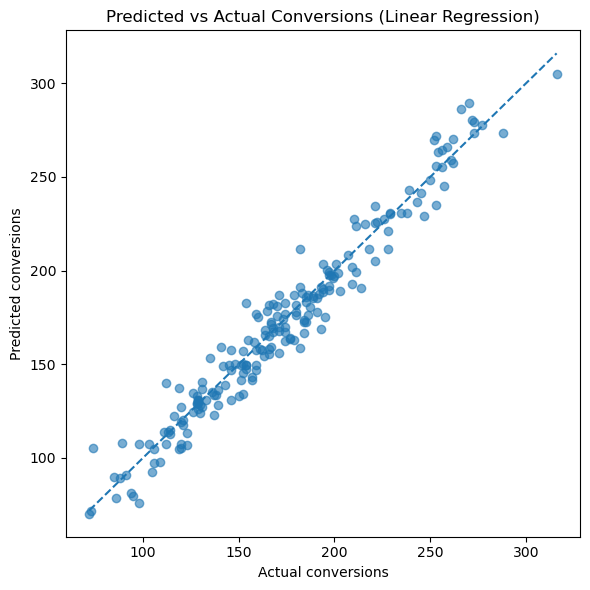

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual conversions")
plt.ylabel("Predicted conversions")
plt.title("Predicted vs Actual Conversions (Linear Regression)")
plt.tight_layout()
plt.show()

### 6.4 Example Relationships

To link the model back to business intuition,  
I plot a couple of simple relationships from the raw data:

- Conversions vs `ad_spend` (colour = creative quality)
- Conversions vs `creative_quality`

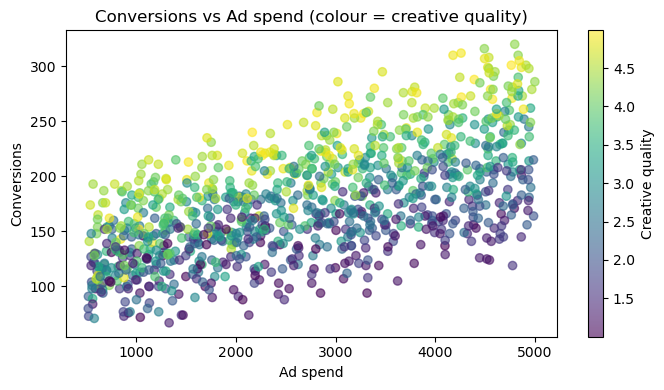

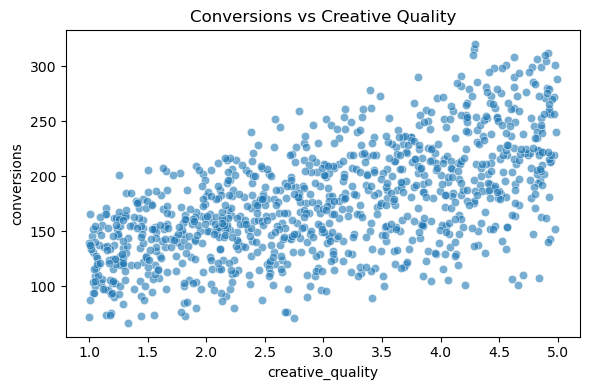

In [20]:
# Conversions vs ad_spend, coloured by creative_quality
plt.figure(figsize=(7, 4))
sc = plt.scatter(
    df["ad_spend"],
    df["conversions"],
    c=df["creative_quality"],
    alpha=0.6
)
plt.xlabel("Ad spend")
plt.ylabel("Conversions")
plt.title("Conversions vs Ad spend (colour = creative quality)")
cbar = plt.colorbar(sc)
cbar.set_label("Creative quality")
plt.tight_layout()
plt.show()

# Conversions vs creative_quality
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df,
    x="creative_quality",
    y="conversions",
    alpha=0.6
)
plt.title("Conversions vs Creative Quality")
plt.tight_layout()
plt.show()

## 7. Random Forest Model

To check whether non-linear relationships and interactions  
can be captured more flexibly, I also train a **Random Forest Regressor**.

This gives:

- another performance benchmark  
- feature importances that highlight which variables (including interactions) drive the model most.

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

r2_rf, mae_rf

(0.9413049182000204, 9.301658662812272)

### 7.1 Feature Importances (Random Forest)

Now I inspect feature importances from the Random Forest  
to see which predictors, including interaction terms, contribute most to performance.

,feature,importance
6,spend_x_creative,0.719997
5,spend_x_audience,0.117025
1,audience_size,0.093631
7,creative_x_season,0.041675
2,creative_quality,0.013997
3,landing_page_quality,0.007549
0,ad_spend,0.004345
4,seasonality_factor,0.001782


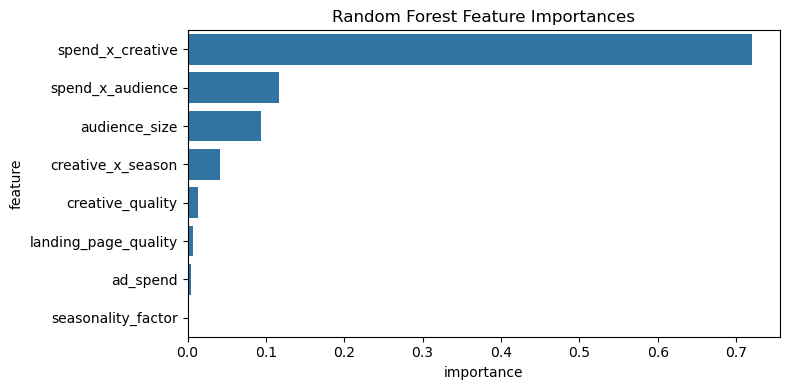

In [22]:
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

display(importances)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=importances,
    x="importance",
    y="feature"
)
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## 8. Business Insights

From the models and feature importances:

- **Base effects**
  - Higher `ad_spend`, `creative_quality`, and `landing_page_quality` are associated with more conversions.
  - `seasonality_factor` matters: peak seasons (higher values) lift performance.

- **Interaction effects**
  - `spend_x_creative`: campaigns with strong creatives benefit more from higher budgets.
  - `spend_x_audience`: spend is more effective on larger audiences.
  - `creative_x_season`: good creatives are especially powerful during high-intent seasons.

**Practical recommendations for a marketing manager:**

- Prioritise budget on campaigns where **creative quality is high AND audience size is large**.
- During **peak seasons**, invest more in top creatives instead of spreading budget thin.
- Avoid overspending on low-quality creatives or very small audiences

  interactions suggest weaker marginal returns there.